In [35]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier

# import precision score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score

%matplotlib inline

In [36]:
# --- Loading the train dataset
train_dataset = pd.read_csv('data/train_dataset.csv')

# --- Loading the dataset
test_dataset = pd.read_csv('data/test_dataset.csv')
    

In [37]:
# --- Defining the function that will use the model to complete the test dataset

def complete_dataset(model_name, model):

    # Loading the test dataset
    test_dataset = pd.read_csv('data/test_dataset.csv')

    # Making the predictions
    test_pred = model.predict(test_dataset)
    test_dataset['Transition'] = test_pred

    # Dropping all columns but the Transition column
    test_dataset.drop(test_dataset.columns.difference(['Transition']), axis=1, inplace=True)

    # Creating a RowId column
    test_dataset['RowId'] = np.arange(1, test_dataset.shape[0] + 1)

    # Placing the RowId column in the first position
    cols = test_dataset.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    test_dataset = test_dataset[cols]

    # Transforming the Transition column back to its original values
    replace_map = {'Transition': {0: 'CN-CN', 1: 'AD-AD', 2: 'CN-MCI', 3: 'MCI-AD', 4: 'MCI-MCI'}}
    test_dataset.replace(replace_map, inplace=True)
    test_dataset.head()

    # Saving the test dataset to a csv file
    test_dataset.to_csv('test_predictions_' + model_name + '.csv', index=False)

In [38]:
# --- Defining features and target
X = train_dataset.drop('Transition', axis=1)
y = train_dataset['Transition']

In [39]:
# Dropping the oversampled column if it exists in features
if 'oversampled' in X.columns:
    X = X.drop(columns=['oversampled'])

# dictionary to store the f1 scores of each model
results = {}

## Random Forest

In [40]:
# --- Implementing a Random Forest Model

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']


rf_model = RandomForestClassifier(
    criterion='entropy',
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=random_state,
)

# Initialize cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    rf_model.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = rf_model.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = rf_model.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
rf_model.fit(X_final_train, y_final_train)


# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['rfc'] = cv_f1
print('Random Forest Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

Random Forest Results:
Cross-validation F1: 0.399


In [41]:
# --- Analyzing the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
rfc_pred = cv_predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, rfc_pred))

Confusion matrix
[[70  5  2  4 15]
 [ 3 26  1 22  8]
 [ 3  0  5  2  0]
 [18 26  1 16  7]
 [32 12  2 12 13]]


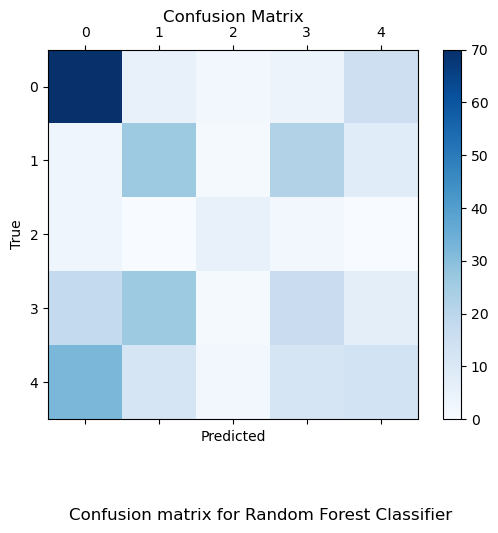

In [42]:

# --- Plotting the confusion matrix
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, rfc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for Random Forest Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [43]:
# --- Completing the test dataset
complete_dataset('RandomForestClassifier', rf_model)

# SVM

In [44]:
# --- Implementing a SVM model

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']


svm = SVC(
    random_state=random_state,
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    C=0.2,
    gamma='scale'
)

# Initialize cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    svm.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = svm.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = svm.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
svm.fit(X_final_train, y_final_train)

# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['svm'] = cv_f1
print('SVM Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

SVM Results:
Cross-validation F1: 0.373


In [45]:
# Complete the dataset
complete_dataset('svm', svm)

## XGBoost

In [46]:
# --- Implementing an XGBoost model

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']

xgbc = xgb.XGBClassifier(
    objective='multi:softprob',
    random_state=random_state,
    num_class=5,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3
)

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    xgbc.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = xgbc.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = xgbc.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
xgbc.fit(X_final_train, y_final_train)


# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['xgbc'] = cv_f1
print('XGBoost Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

XGBoost Results:
Cross-validation F1: 0.451


In [47]:
# --- Analyzing the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
xgbc_pred = cv_predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, xgbc_pred))

Confusion matrix
[[76  2  0  5 13]
 [ 7 30  1 18  4]
 [ 3  0  6  1  0]
 [15 26  1 17  9]
 [33 12  1 13 12]]


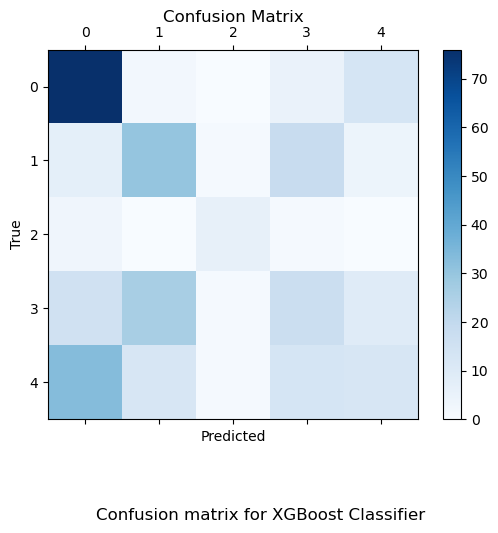

In [48]:
# --- Plotting the confusion matrix with a caption
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, xgbc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for XGBoost Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [49]:
# Completing the test dataset
complete_dataset('xgboost', xgbc)

## Logistic Regression

In [50]:
# --- Implementing a Logistic Regression model

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']


# Initializing the logistic regression model with pipeline
log_reg = LogisticRegression(
    random_state=random_state,
    max_iter=5000,
    class_weight='balanced',
    C=0.1,
    penalty='l1',
    solver='saga'  # needed for l1 penalty with multinomial
)

# Initialize cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    log_reg.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = log_reg.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = log_reg.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
log_reg.fit(X_final_train, y_final_train)


# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['logreg'] = cv_f1
print('Logistic Regression Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

Logistic Regression Results:
Cross-validation F1: 0.378


In [51]:
# Complete the dataset
complete_dataset('logreg', log_reg)

# LightGBM

In [52]:
# --- Implementing a LightGBM model
random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']


lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    random_state=random_state,
    num_class=5,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    class_weight='balanced',
    min_child_samples=5,        # Lower minimum samples per leaf
    min_split_gain=0.0,        # Allow splits with smaller gains
    feature_fraction=0.8,       # Use only 80% of features per tree
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=0.1,            # L2 regularization
    verbose=-1                  # Reduce verbosity
)

# Initialize cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    lgbm.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = lgbm.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = lgbm.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
lgbm.fit(X_final_train, y_final_train)


# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['lgbm'] = cv_f1
print('LightGBM Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

LightGBM Results:
Cross-validation F1: 0.409


In [53]:
# Complete the dataset
complete_dataset('lightgbm', lgbm)

# Stacking Classifier

In [54]:
# Cria o Stacking Classifier
stacking_model = StackingClassifier(
    estimators=[
        ('rfc', rf_model),
        ('xgboost', xgbc),
        ('svm', svm),
        ('lr', log_reg),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=0.1
    ),  # Meta-modelo para combinar previsões
    cv=5
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    stacking_model.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = stacking_model.predict(X.loc[actual_val_idx])
    val_prob = stacking_model.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['st']= final_f1_macro

print('\nFinal Stacking Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')


Final Stacking Results
Overall Macro F1 Score: 0.394


In [55]:
# Complete the dataset
complete_dataset('stacking', stacking_model)

# Stacking Classifier 2

In [56]:
# Cria o Stacking Classifier
stacking_model_2 = StackingClassifier(
    estimators=[
        ('rfc', rf_model),
        ('xgboost', xgbc),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=0.1
    ),  # Meta-modelo para combinar previsões
    cv=5
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    stacking_model_2.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = stacking_model_2.predict(X.loc[actual_val_idx])
    val_prob = stacking_model_2.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['st2']= final_f1_macro

print('\nFinal Stacking 2 Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')


Final Stacking 2 Results
Overall Macro F1 Score: 0.359


In [57]:
# Complete the dataset
complete_dataset('stacking2', stacking_model_2)

# Voting Classifier

In [58]:
# Cria o Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ('rfc', rf_model),
        ('xgboost', xgbc),
        ('svm', svm),
        ('lr', log_reg),
        ('lgbm', lgbm)
    ],
    voting='soft'  # ou 'hard' para votação majoritária
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    voting_model.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = voting_model.predict(X.loc[actual_val_idx])
    val_prob = voting_model.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['vote']= final_f1_macro

print('\nFinal Voting Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')


Final Voting Results
Overall Macro F1 Score: 0.467


In [59]:
# Complete the dataset
complete_dataset('voting', voting_model)

# Voting Classifier 2

In [60]:
# Cria o Voting Classifier
voting_model_2 = VotingClassifier(
    estimators=[
        ('rfc', rf_model),
        ('xgboost', xgbc),
        ('lgbm', lgbm)
    ],
    voting='soft'  # ou 'hard' para votação majoritária
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    voting_model_2.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = voting_model_2.predict(X.loc[actual_val_idx])
    val_prob = voting_model_2.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['vote2']= final_f1_macro

print('\nFinal Voting 2 Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')


Final Voting 2 Results
Overall Macro F1 Score: 0.414


In [61]:
# Complete the dataset
complete_dataset('voting2', voting_model)

# Resultados de cada Modelo

In [62]:
for model in results:
    print(f"Modelo: {model} - Score: {results[model]}")

Modelo: rfc - Score: 0.39921131471650684
Modelo: svm - Score: 0.37334350132625993
Modelo: xgbc - Score: 0.4505717969905939
Modelo: logreg - Score: 0.3779419540666785
Modelo: lgbm - Score: 0.40917056733588997
Modelo: st - Score: 0.3942931480284421
Modelo: st2 - Score: 0.35876119271315776
Modelo: vote - Score: 0.4670258980785296
Modelo: vote2 - Score: 0.4135047072604297


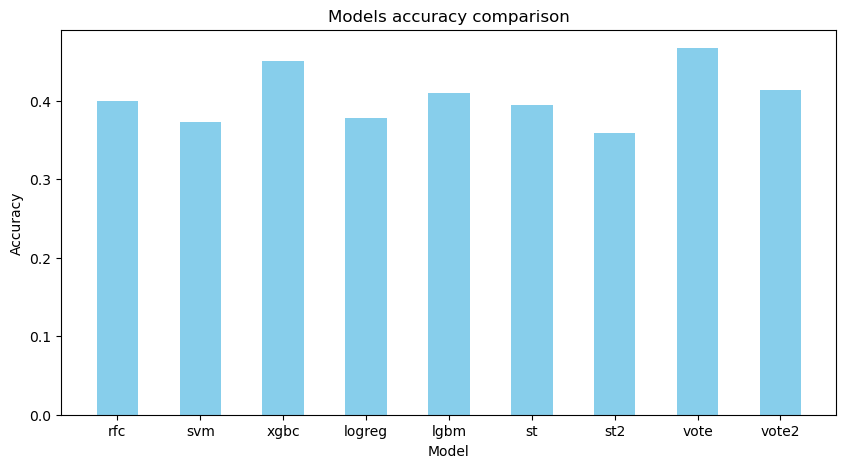

In [63]:
fig = plt.figure(figsize = (10, 5))

mod = results.keys()
acc = results.values()

plt.bar(mod, acc, color='skyblue', width = 0.5)
 
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Models accuracy comparison")

plt.show()